# PRCP-1024-TexasSalaryPrediction

# 1.IMPORTING LIBRARIES AND LOADING DATA

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , OrdinalEncoder
#importing models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor ,GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
#evaluation
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\salary.csv")

In [4]:
df.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


# 2.DATA UNDERSTANDING AND STRUCTURE

In [5]:
print('='*100)
print("COLUMN INFO")
print('='*100)
df.columns

COLUMN INFO


Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

In [6]:
print('='*100)
print("DATA INFO")
print('='*100)
df.info()

DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64

In [7]:
print('='*100)
print("STATISTICAL SUMMARY")
print('='*100)
df.describe()

STATISTICAL SUMMARY


,AGENCY,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,multiple_full_time_jobs,summed_annual_salary
count,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,1.494810e+05,14.0,16.000000
mean,545.736288,0.346488,39.714918,4226.184248,50714.210973,5.651930e+05,1.0,74303.955000
std,139.057691,4.211485,2.323855,2093.111691,25117.340292,4.786212e+05,0.0,51925.944282
min,101.000000,0.000000,1.000000,50.000000,600.000000,1.000000e+00,1.0,18000.000000
25%,529.000000,0.000000,40.000000,3019.840000,36238.080000,1.133340e+05,1.0,32962.500000
50%,530.000000,0.000000,40.000000,3720.170000,44642.040000,3.463730e+05,1.0,48063.300000
75%,696.000000,0.000000,40.000000,4865.810000,58389.720000,1.100500e+06,1.0,123751.770000
max,930.000000,117.788480,70.000000,46125.000000,553500.000000,1.271604e+06,1.0,171383.400000


# 3.DATA QUALITY AND ASSESSMENT

In [8]:
df.drop(['STATE NUMBER', 'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
         'summed_annual_salary', 'hide_from_search'], axis=1, inplace=True)

In [9]:
df.shape

(149481, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   AGENCY       149481 non-null  int64  
 1   AGENCY NAME  149481 non-null  object 
 2   LAST NAME    149481 non-null  object 
 3   FIRST NAME   149481 non-null  object 
 4   MI           149481 non-null  object 
 5   CLASS CODE   149481 non-null  object 
 6   CLASS TITLE  149481 non-null  object 
 7   ETHNICITY    149481 non-null  object 
 8   GENDER       149481 non-null  object 
 9   STATUS       149481 non-null  object 
 10  EMPLOY DATE  149481 non-null  object 
 11  HRLY RATE    149481 non-null  float64
 12  HRS PER WK   149481 non-null  float64
 13  MONTHLY      149481 non-null  float64
 14  ANNUAL       149481 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 17.1+ MB


In [11]:
# FINDING NULL VALUES

In [12]:
df.isnull().sum()

AGENCY         0
AGENCY NAME    0
LAST NAME      0
FIRST NAME     0
MI             0
CLASS CODE     0
CLASS TITLE    0
ETHNICITY      0
GENDER         0
STATUS         0
EMPLOY DATE    0
HRLY RATE      0
HRS PER WK     0
MONTHLY        0
ANNUAL         0
dtype: int64

In [13]:
# finding outliers

<Axes: >

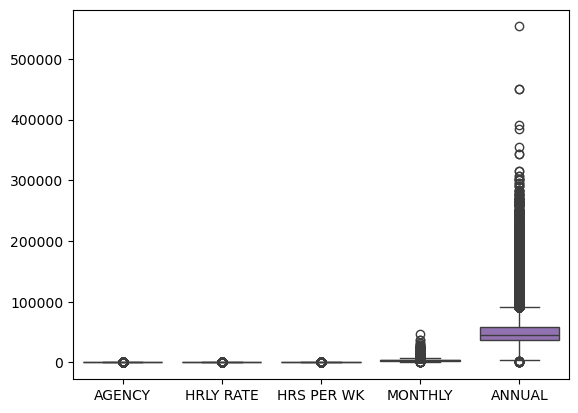

In [14]:
sns.boxplot(data=df)

<Axes: xlabel='ANNUAL'>

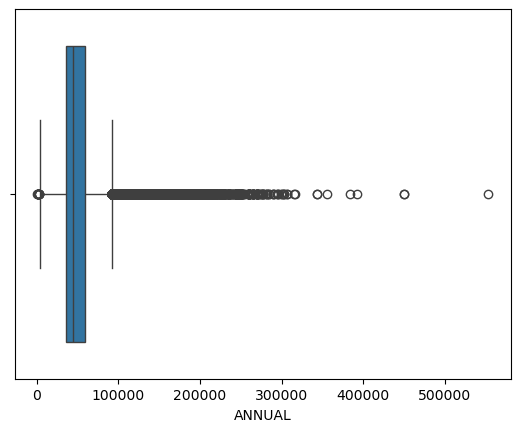

In [15]:
# HANDLING OUTLIERS
sns.boxplot(x=df['ANNUAL'])

<Axes: xlabel='MONTHLY'>

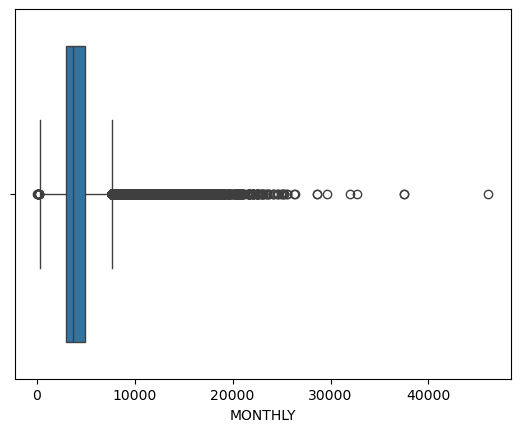

In [16]:
sns.boxplot(x=df['MONTHLY'])

In [17]:
import numpy as np
import pandas as pd

# Define the find_boundaries function
def find_boundaries(column_name):
    """
    Calculate lower and upper boundaries for outlier detection using IQR method
    """

    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return lower_bound, upper_bound



lower_ANNUAL, upper_ANNUAL = find_boundaries('ANNUAL')
print(lower_ANNUAL, upper_ANNUAL)

# Cap the outliers / censoring the outliers
df.ANNUAL = np.where(df.ANNUAL > upper_ANNUAL, upper_ANNUAL, df.ANNUAL)
df.ANNUAL = np.where(df.ANNUAL < lower_ANNUAL, lower_ANNUAL, df.ANNUAL)



3010.6200000000026 91617.18


In [18]:
Q1 = df['MONTHLY'].quantile(0.25)  
Q3 = df['MONTHLY'].quantile(0.75) 
IQR = Q3 - Q1
IQR

np.float64(1845.9700000000003)

In [19]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

250.88499999999976
7634.765000000001


In [20]:
df = df[(df['MONTHLY']>=lower_bound) & (df['MONTHLY']<=upper_bound)]

In [21]:
# checking if outliers are removed

<Axes: xlabel='ANNUAL'>

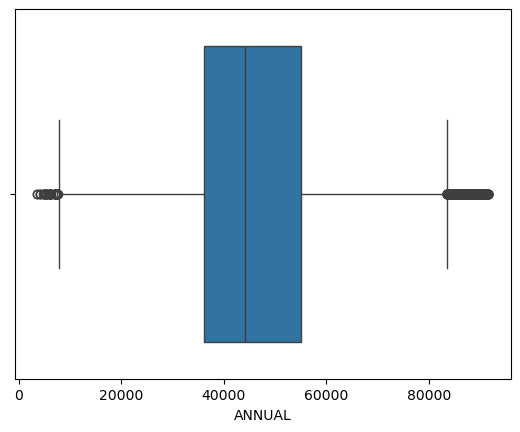

In [22]:
sns.boxplot(x=df['ANNUAL'])

<Axes: xlabel='MONTHLY'>

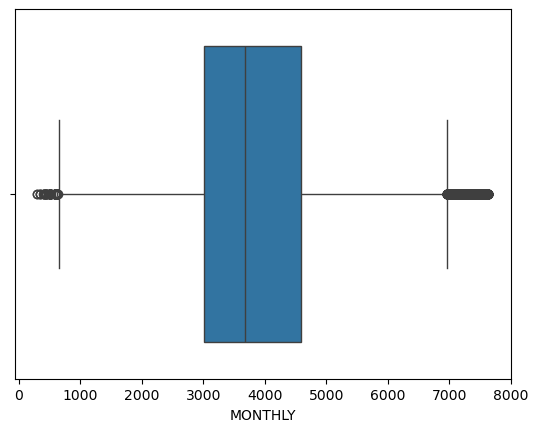

In [23]:
sns.boxplot(x=df['MONTHLY'])

# 4.EXPLORATORY DATA ANALYSIS

In [24]:
#UNIVARIATE ANALYSIS

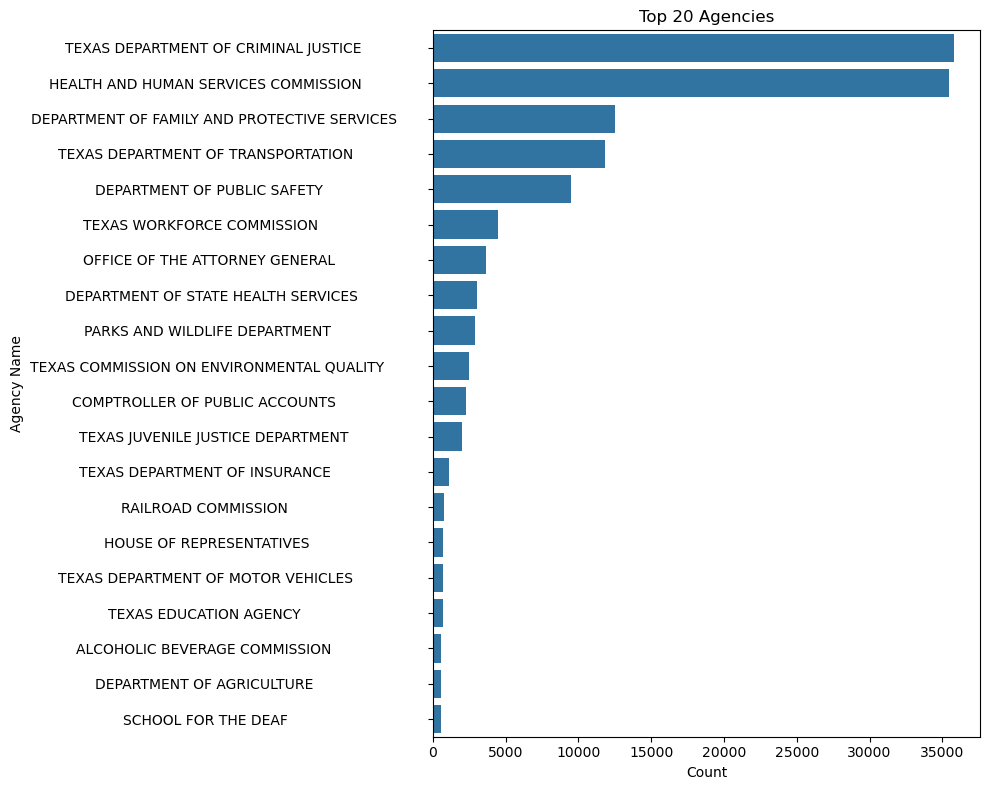

In [25]:
top_20_agencies = df['AGENCY NAME'].value_counts().head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_agencies.values, y=top_20_agencies.index, orient='h') 
plt.xlabel('Count')
plt.ylabel('Agency Name')
plt.title('Top 20 Agencies')
plt.tight_layout()
plt.show()

Based on the visual data, here are two key insights:

1.Significant Resource Concentration:

The Texas Department of Criminal Justice and the Health and Human Services Commission drastically outpace all other agencies, indicating that a vast majority of the dataset's records (likely employees) are concentrated in just two sectors.
2.Rapid Distribution Decay:

There is a "long tail" effect where the top five agencies represent the bulk of the volume, while the remaining 15 agencies show a sharp decline and relatively uniform, minimal counts.

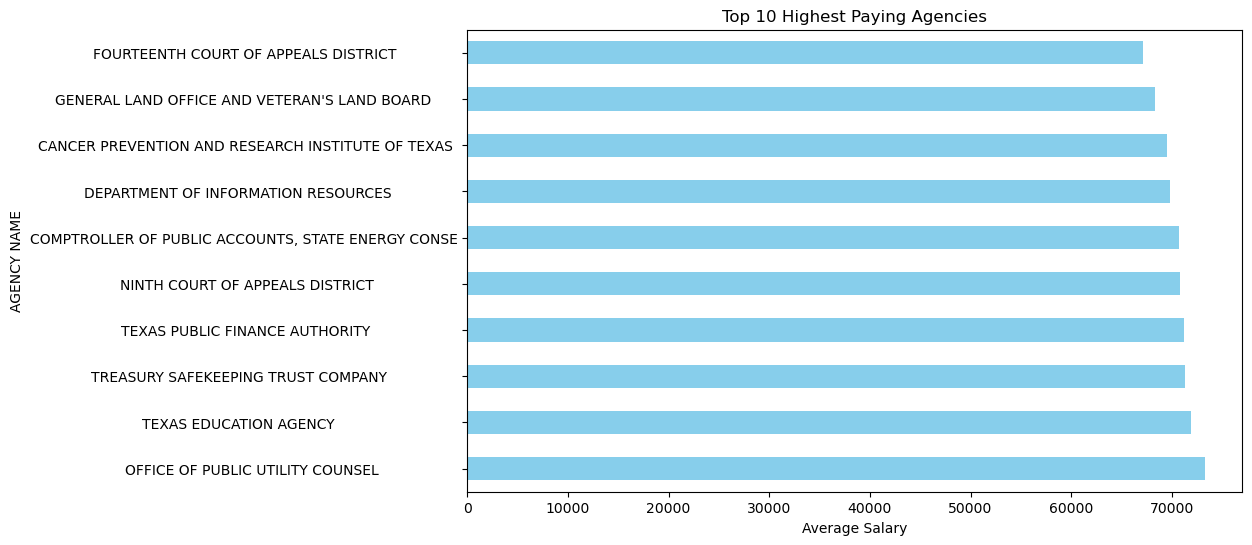

In [26]:
top_10_data = df.groupby('AGENCY NAME')['ANNUAL'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))  
top_10_data.plot(kind='barh', color='skyblue')  
plt.title('Top 10 Highest Paying Agencies')
plt.xlabel('Average Salary')
plt.show()

Key Observations

1.High-Paying Agencies

The Fourteenth Court of Appeals District and General Land Office & Veteran’s Land Board top the list, indicating that judicial and land-related agencies offer the highest average salaries.

Specialized agencies like the Cancer Prevention and Research Institute of Texas and Department of Information Resources also rank highly, reflecting the premium placed on specialized expertise (healthcare research, IT governance).

2.Sectoral Trends

Judicial agencies (Courts of Appeals) appear multiple times, suggesting that legal and judicial roles consistently command higher compensation.

Financial oversight agencies (Texas Public Finance Authority, Treasury Safekeeping Trust Company) also feature prominently, highlighting the value of financial management expertise in the public sector.

3.Policy & Strategic Implications

Agencies with higher salaries may attract and retain top talent, but they also contribute to wage disparities across the public sector.

Lower-paying agencies may face challenges in recruitment and retention, especially for specialized roles, unless they offer non-monetary incentives (job security, benefits, career progression).

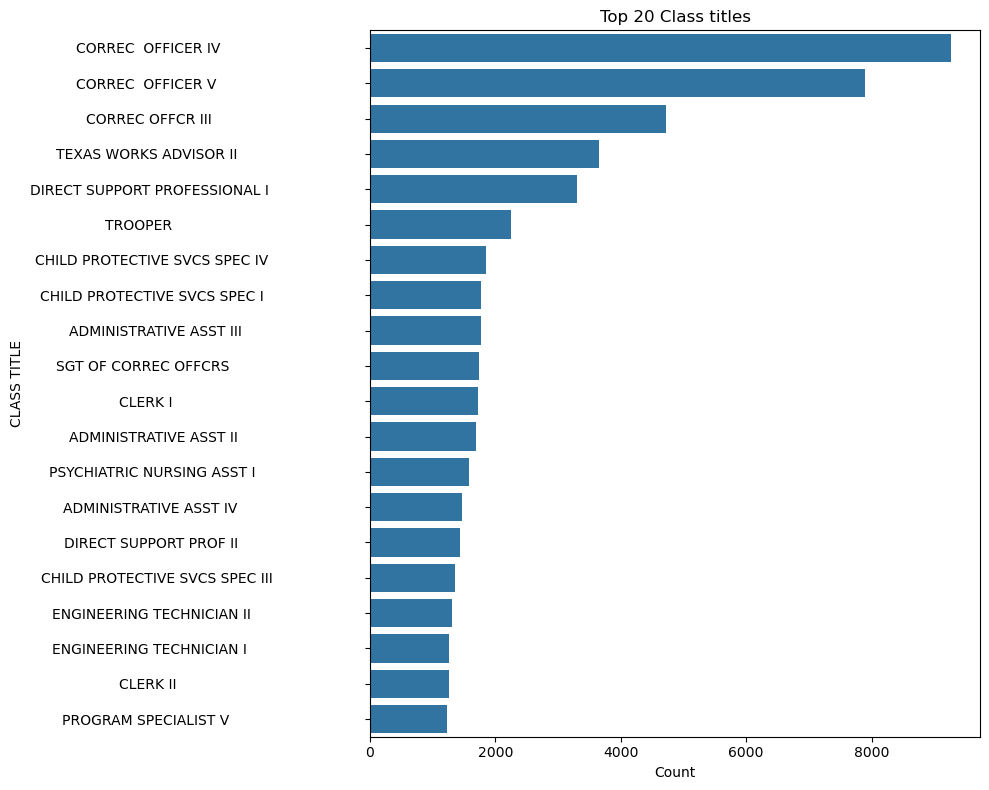

In [27]:
top_20_class_titles = df['CLASS TITLE'].value_counts().head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_class_titles.values, y=top_20_class_titles.index, orient='h') 
plt.xlabel('Count')
plt.ylabel('CLASS TITLE')
plt.title('Top 20 Class titles')
plt.tight_layout()
plt.show()

Based on the exploratory data analysis (EDA) of the Texas Salary Prediction dataset, here are two professional insights:

1.Dominance of Public Safety Roles:

The dataset is heavily skewed toward correctional and law enforcement positions, suggesting that Correctional Officers (Levels III-V) will be the primary drivers of any predictive model's variance.
2.Need for Feature Engineering:

Given the high frequency of similar titles with varying seniority levels (e.g., Admin Asst II, III, IV), extracting numerical seniority levels from these text strings will be crucial for improving the model's predictive accuracy regarding salary

<Axes: xlabel='ETHNICITY', ylabel='Count'>

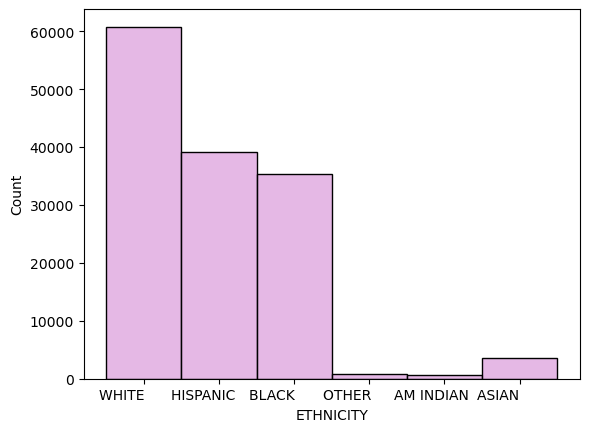

In [28]:
sns.histplot(x=df['ETHNICITY'],edgecolor= 'black',color='plum')

INSIGHTS : White ethnicity is the dominant employeed category while am indian and asians are lowest

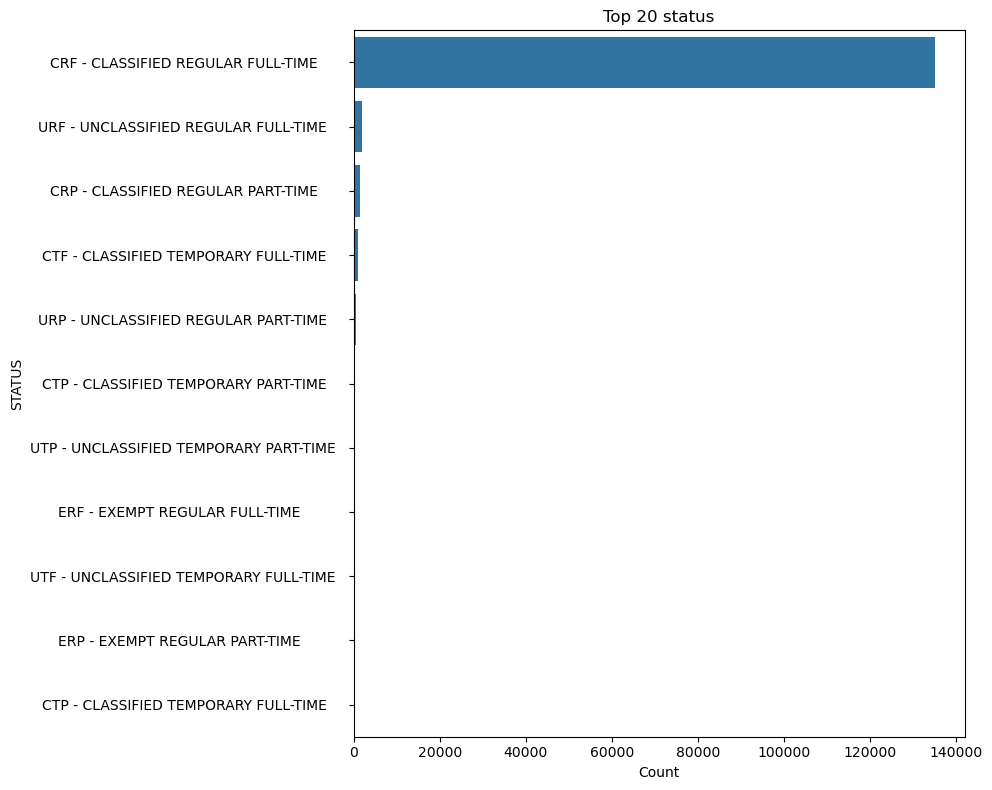

In [29]:
top_20_status = df['STATUS'].value_counts().head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_status.values, y=top_20_status.index, orient='h') 
plt.xlabel('Count')
plt.ylabel('STATUS')
plt.title('Top 20 status')
plt.tight_layout()
plt.show()

In [30]:
df[df['STATUS'] == 'CRF - CLASSIFIED REGULAR FULL-TIME']['STATUS'].value_counts()

Series([], Name: count, dtype: int64)

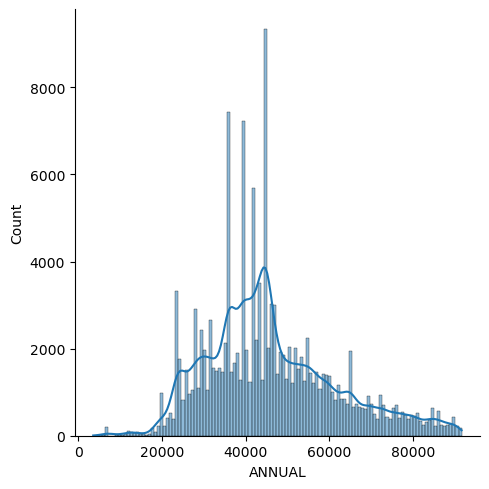

In [31]:
sns.displot(x=df['ANNUAL'],kde=True)

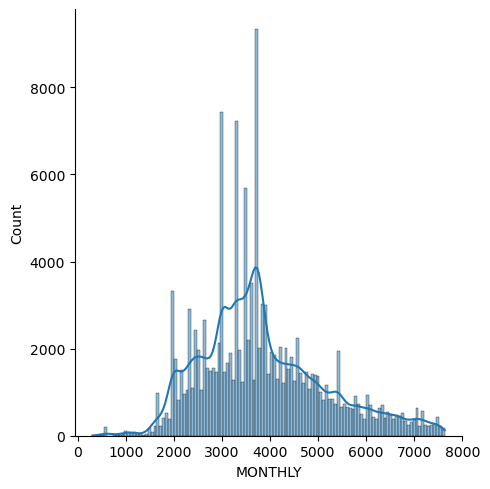

In [32]:
sns.displot(x=df['MONTHLY'],kde=True)

In [33]:
# PIVOT TABLE

In [34]:
pd.pivot_table(df, index = ['STATUS','AGENCY NAME'], values = 'ANNUAL')

ANNUAL
STATUS                                   AGENCY NAME                                                     
CRF - CLASSIFIED REGULAR FULL-TIME       ALCOHOLIC BEVERAGE COMMISSION                       55981.286596
                                         BOARD OF ARCHITECTURAL EXAMINERS                    69828.150000
                                         BOARD OF CHIROPRACTIC EXAMINERS                     59073.386667
                                         BOARD OF DENTAL EXAMINERS                           49548.181132
                                         BOARD OF EXAMINERS OF PSYCHOLOGISTS                 48445.975385
...                                                                                                   ...
UTF - UNCLASSIFIED TEMPORARY FULL-TIME   SENATE                                              32653.333333
UTP - UNCLASSIFIED TEMPORARY PART-TIME   HOUSE OF REPRESENTATIVES                            60000.000000
                                         SCHOOL FOR THE BLIND AND VISUALLY IMPAIRED          13666.620000
                                         SENATE                                              15201.032000
                                         TEXAS LEGISLATIVE COUNCIL                           56289.000000

[226 rows x 1 columns]

In [35]:
pd.pivot_table(df, index = ['AGENCY NAME'], values = ['CLASS TITLE'], aggfunc = 'count')

,CLASS TITLE
AGENCY NAME,
ALCOHOLIC BEVERAGE COMMISSION,583
BOARD OF ARCHITECTURAL EXAMINERS,14
BOARD OF CHIROPRACTIC EXAMINERS,9
BOARD OF DENTAL EXAMINERS,53
BOARD OF EXAMINERS OF PSYCHOLOGISTS,15
...,...
THIRD COURT OF APPEALS DISTRICT,9
THIRTEENTH COURT OF APPEALS DISTRICT,10
TREASURY SAFEKEEPING TRUST COMPANY,24


In [36]:
pd.pivot_table(df, index = ['AGENCY NAME','CLASS TITLE','STATUS'], values = 'ANNUAL')

ANNUAL
AGENCY NAME                                        CLASS TITLE                                        STATUS                                            
ALCOHOLIC BEVERAGE COMMISSION                      ACCOUNTANT I                                       CRF - CLASSIFIED REGULAR FULL-TIME        39263.52
                                                   ACCOUNTANT II                                      CRF - CLASSIFIED REGULAR FULL-TIME        42500.04
                                                   ACCOUNTANT IV                                      CRF - CLASSIFIED REGULAR FULL-TIME        51000.00
                                                   ACCOUNTANT VI                                      CRF - CLASSIFIED REGULAR FULL-TIME        63543.48
                                                   ACCTS EXAM I                                       CRF - CLASSIFIED REGULAR FULL-TIME        36000.00
...                                                                                                                                                  ...
WATER DEVELOPMENT BOARD                            SYSTEMS ANALYST V                                  CRF - CLASSIFIED REGULAR FULL-TIME        82745.04
                                                   SYSTEMS SUPPORT SPECIALIST II                      CRF - CLASSIFIED REGULAR FULL-TIME        48000.00
                                                   SYSTEMS SUPPORT SPECIALIST III                     CRF - CLASSIFIED REGULAR FULL-TIME        52722.36
                                                   WEB ADMINISTRATOR III                              CRF - CLASSIFIED REGULAR FULL-TIME        72381.12
                                                   WEB ADMINISTRATOR V                                CRF - CLASSIFIED REGULAR FULL-TIME        87178.08

[6605 rows x 1 columns]

In [37]:
pd.pivot_table(df,index=['CLASS TITLE','STATUS'],values=['ANNUAL'])

,,ANNUAL
CLASS TITLE,STATUS,
14 CUSTOMER SERVICES REP,URF - UNCLASSIFIED REGULAR FULL-TIME,40403.177143
19 EXECUTIVE ASSISTANT,URF - UNCLASSIFIED REGULAR FULL-TIME,64992.960000
20 PROGRAM SPECIALIST III,URF - UNCLASSIFIED REGULAR FULL-TIME,59445.274286
21 BUSINESS ANALYST,URF - UNCLASSIFIED REGULAR FULL-TIME,64422.800000
21 SYSTEMS ADMINISTRATOR III,URF - UNCLASSIFIED REGULAR FULL-TIME,58375.020000
...,...,...
WRITING SPEC I,URF - UNCLASSIFIED REGULAR FULL-TIME,39249.960000
WRITING SPEC II,URF - UNCLASSIFIED REGULAR FULL-TIME,42999.960000
WRITING SPECIALIST III,URF - UNCLASSIFIED REGULAR FULL-TIME,49451.920000


In [38]:
pd.pivot_table(df, index=['ETHNICITY'], values='ANNUAL', aggfunc='count')

,ANNUAL
ETHNICITY,
AM INDIAN,664
ASIAN,3612
BLACK,35278
HISPANIC,39223
OTHER,887
WHITE,60786


In [39]:
# BIVARIATE ANALYSIS

<Axes: xlabel='ANNUAL', ylabel='AGENCY NAME'>

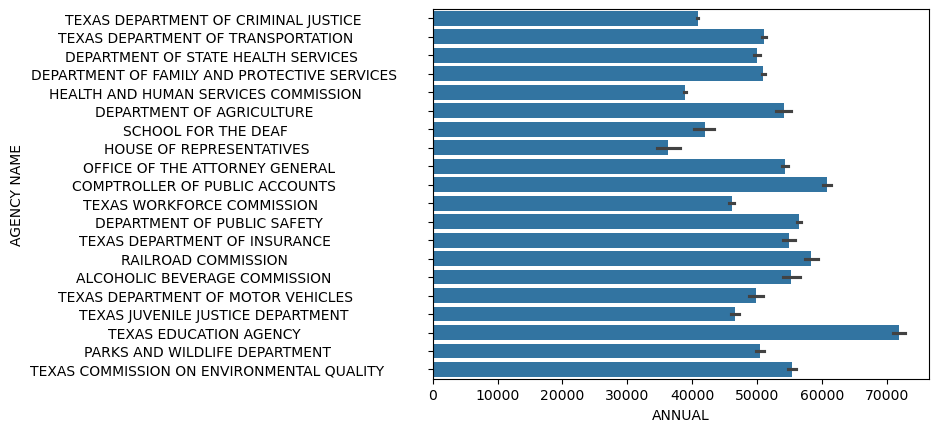

In [40]:
top_20_names = df['AGENCY NAME'].value_counts().head(20).index
filtered = df[df['AGENCY NAME'].isin(top_20_names)]

sns.barplot(
    data=filtered,
    x='ANNUAL',
    y='AGENCY NAME',
    estimator=np.mean
)


Large agencies such as the Department of Criminal Justice and Department of Transportation dominate headcount, yet their average salaries are comparatively lower, reflecting scale-driven workforce structures rather than premium compensation.

In contrast, specialized agencies like the House of Representatives and Office of the Attorney General show higher mean salaries, highlighting how expertise‑intensive roles command stronger pay despite smaller staff sizes.

<function matplotlib.pyplot.show(close=None, block=None)>

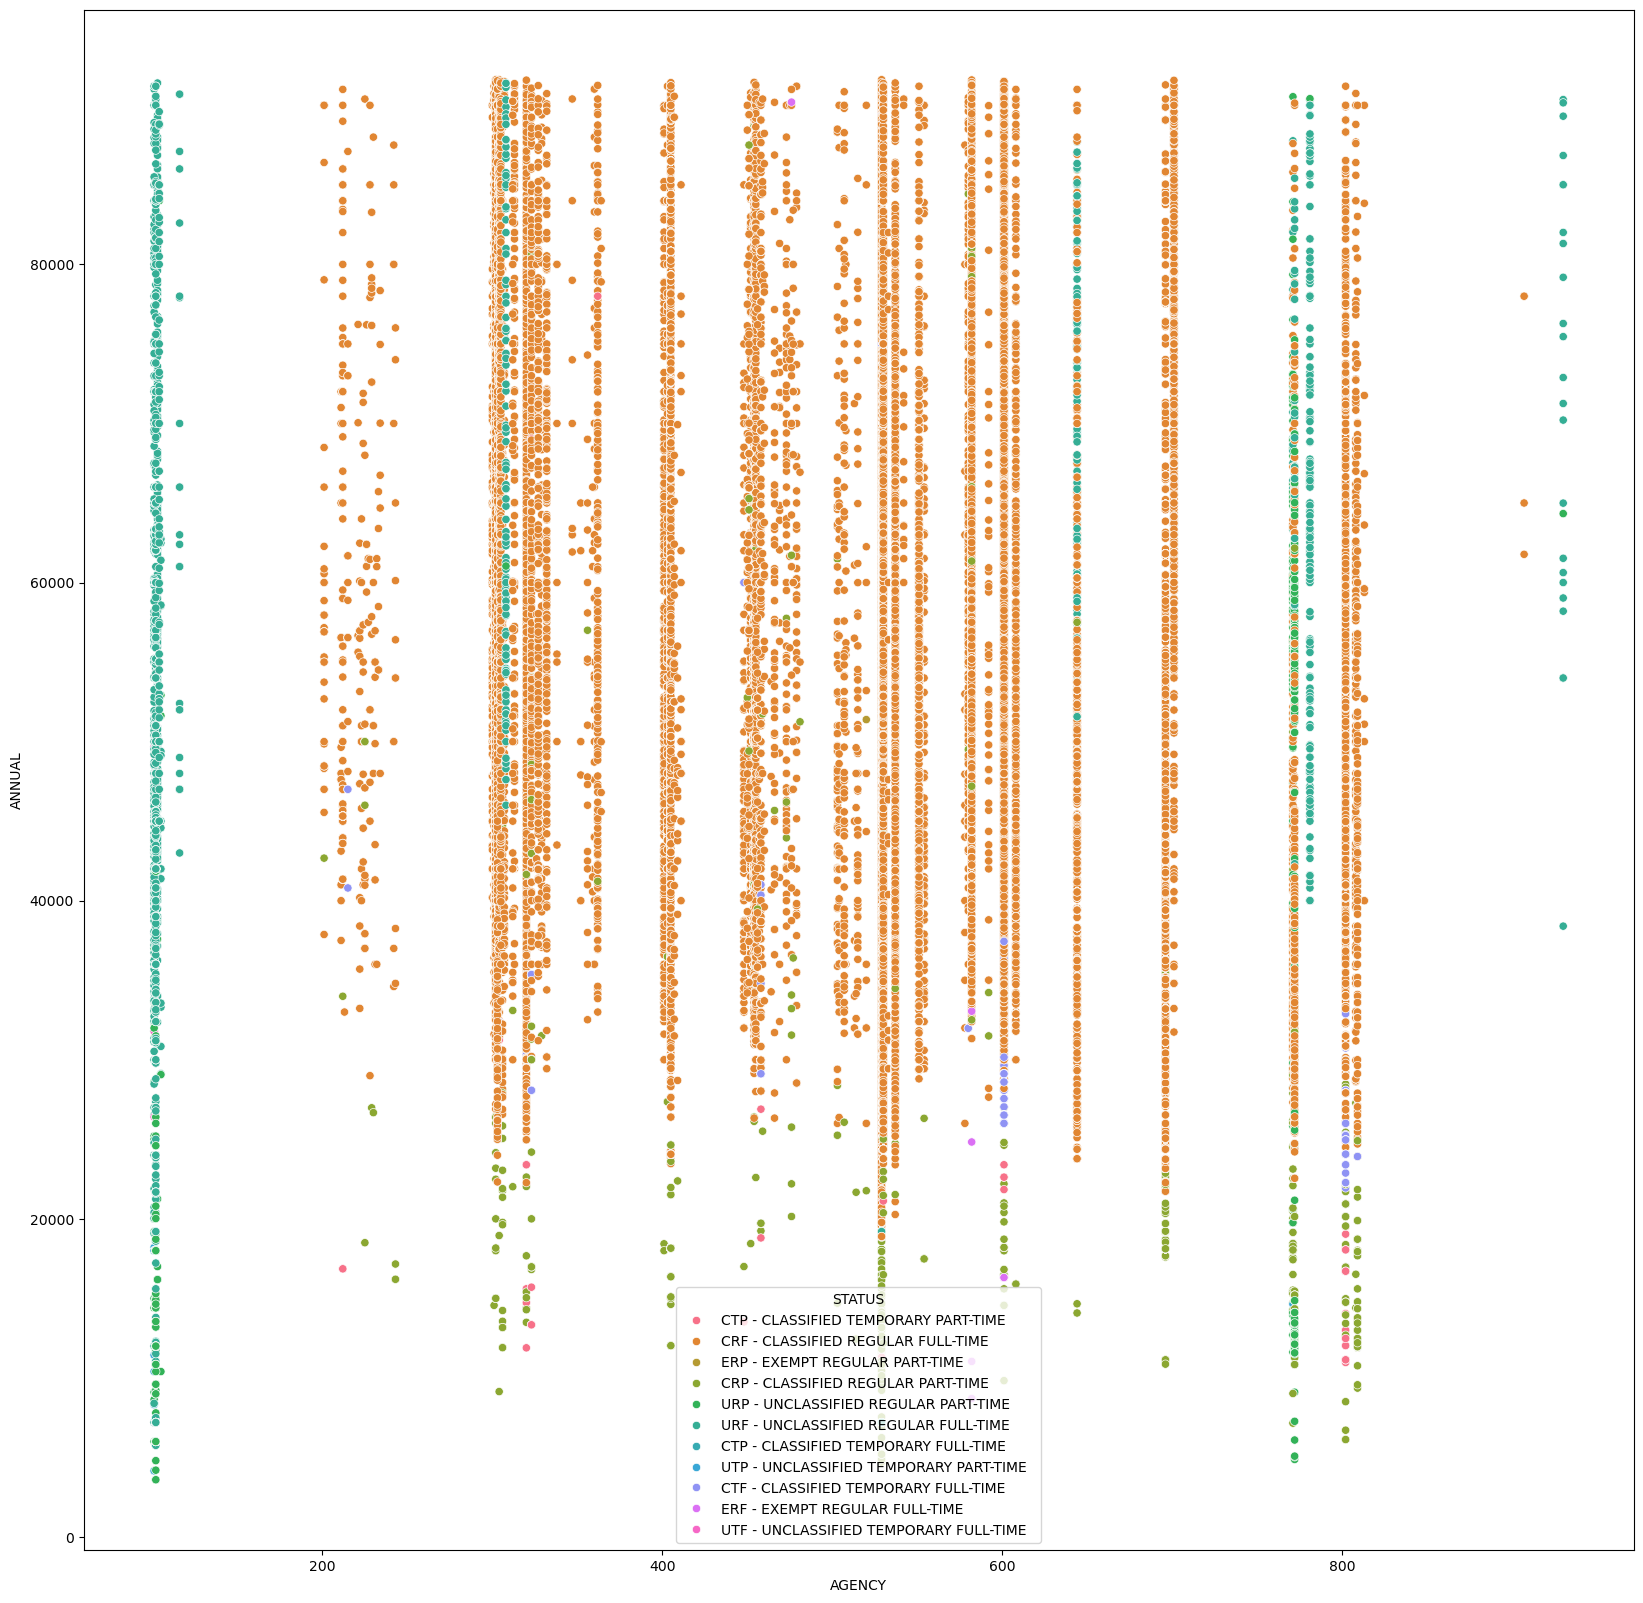

In [41]:
plt.figure(figsize=(20,20))
sns.scatterplot(x='AGENCY', y='ANNUAL', data=df, hue='STATUS')
plt.show

In [42]:
# Find top 20 class titles by hourly rate
top_20_classes = (
    df.groupby('CLASS TITLE')['HRLY RATE']
      .mean()   # average hourly rate per class title
      .sort_values(ascending=False)
      .head(20)
)

print(top_20_classes)

CLASS TITLE
PSYCHIATRIST II                                       85.162910
DIRECTOR V                                            82.635000
GENERAL COUNSEL IV                                    81.044535
EXEC DIR, BD OF EXAMS OF PSYCHOLOGISTS                49.407170
PHYSICIAN II                                          48.862630
PHYSICIAN III                                         19.086423
SUBSTITUTE WORKERS                                    17.430693
HOURLY/SUBSTITUTES                                    15.654069
COMPUTER OPERATIONS SPEC II                           12.000000
ENGINEERING AIDE                                      11.881088
LIFEGUARD                                             11.756633
MAINTENANCE SPECIALIST I                              10.319828
ADMIN ASSNT II                                        10.279883
ADMIN TECHN III                                       10.054170
CUSTOMER SERVICE REP I                                 7.793518
ARCHEOLOGIST I              

Specialized medical and executive roles such as Psychiatrist II and Director V command the highest hourly rates, reflecting the premium placed on advanced expertise and leadership responsibilities.

In contrast, operational and support positions like Maintenance Specialist I and Lifeguard earn significantly lower rates, highlighting the wide compensation gap between specialized professional services and general workforce roles.

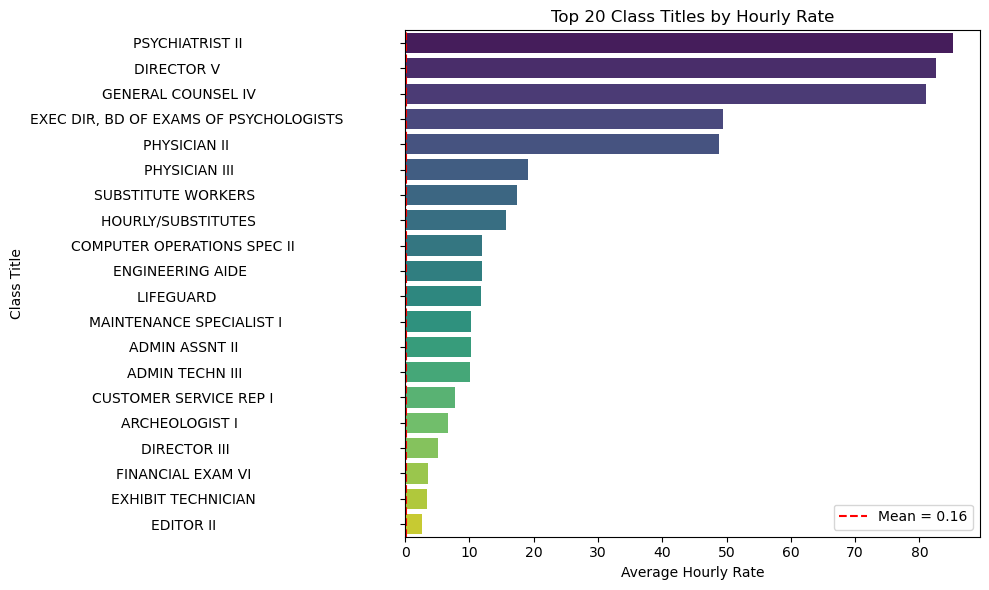

In [43]:
import numpy as np

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_20_classes.values,
    y=top_20_classes.index,
    palette="viridis"
)

# Add overall mean line
mean_rate = df['HRLY RATE'].mean()
plt.axvline(mean_rate, color='red', linestyle='--', label=f'Mean = {mean_rate:.2f}')

# Add title and labels
plt.title("Top 20 Class Titles by Hourly Rate")
plt.xlabel("Average Hourly Rate")
plt.ylabel("Class Title")

# Show legend for mean line
plt.legend()

plt.tight_layout()
plt.show()


<Figure size 2000x2000 with 0 Axes>

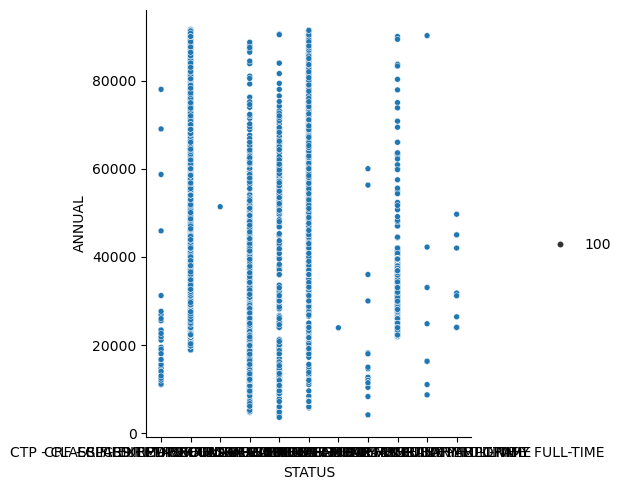

In [44]:
plt.figure(figsize=(20,20))
sns.relplot(x='STATUS',y='ANNUAL',data=df, size=100)

<Figure size 2000x2000 with 0 Axes>

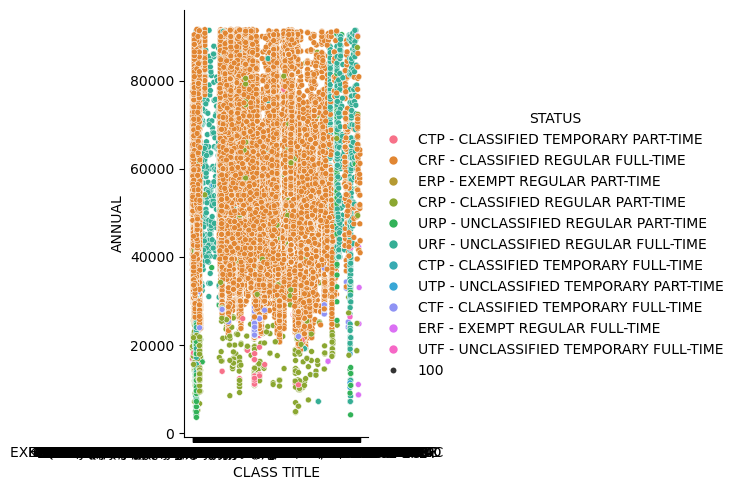

In [45]:
plt.figure(figsize=(20,20))
sns.relplot(x='CLASS TITLE',y='ANNUAL',data=df,hue='STATUS',size=100)

<Axes: xlabel='ETHNICITY', ylabel='ANNUAL'>

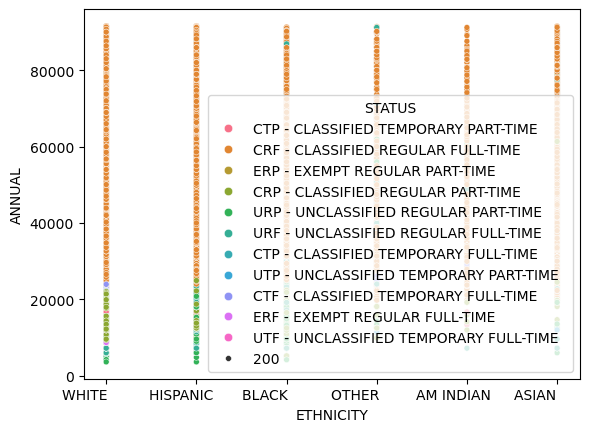

In [46]:

sns.scatterplot(
    data=df,
    x='ETHNICITY',
    y='ANNUAL',hue='STATUS',size=(200)
)


Text(0.5, 1.0, 'ETHNICITY vs ANNUAL')

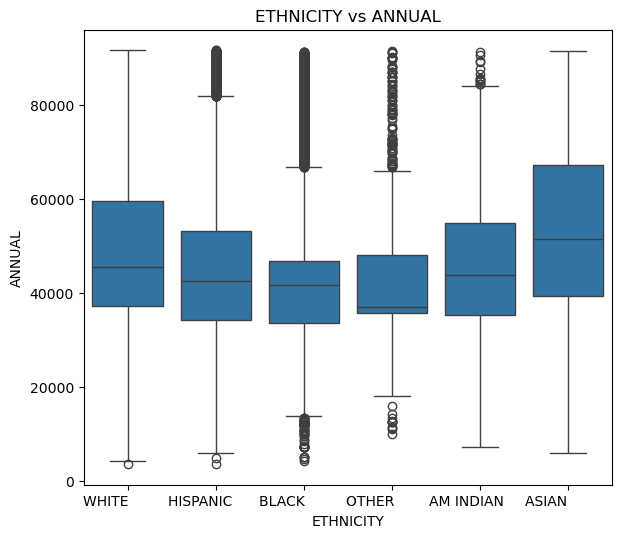

In [47]:
plt.figure(figsize=(15,13))

plt.subplot(2,2,1)
sns.boxplot(x="ETHNICITY",y="ANNUAL",data=df)
plt.title("ETHNICITY vs ANNUAL")

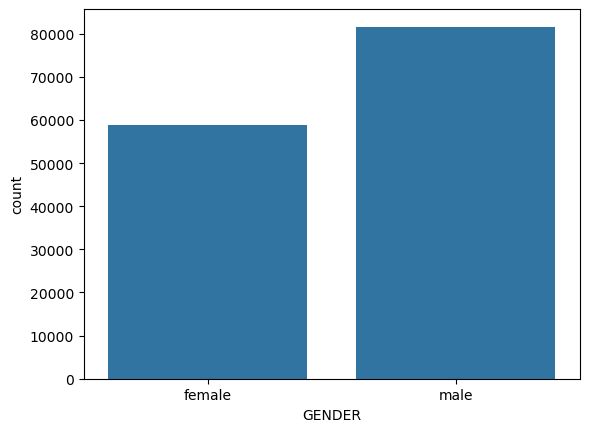

In [48]:
import matplotlib.pyplot as plt
ax = sns.countplot(x=df['GENDER'])
ax.set_xticklabels(['female', 'male'])
plt.show()

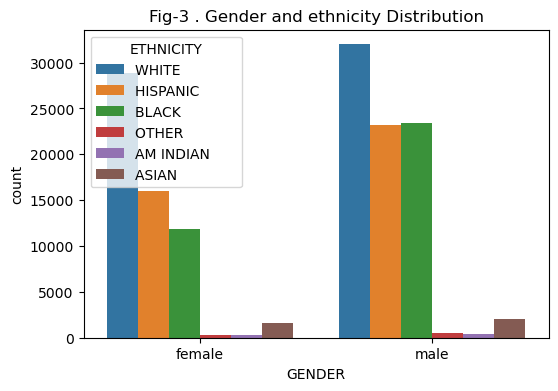

In [49]:
plt.figure(figsize=(6,4))
ax=sns.countplot(x="GENDER",hue="ETHNICITY",data=df)
ax.set_xticklabels(['female', 'male'])
plt.title("Fig-3 . Gender and ethnicity Distribution")
plt.show()

The distribution shows that White employees dominate across both genders, followed by Hispanic and Black groups, highlighting demographic concentration in the workforce.

Minority groups such as Asian, American Indian, and Other ethnicities are represented in much smaller counts, pointing to potential diversity gaps that organizations may need to address.

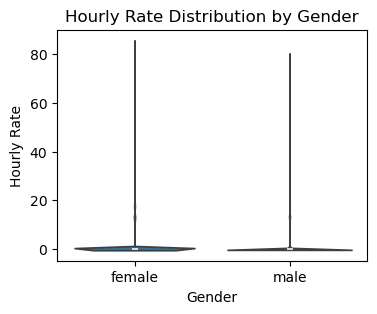

In [50]:
plt.figure(figsize=(4, 3))
ax=sns.violinplot(x='GENDER', y='HRLY RATE', data=df)
ax.set_xticklabels(['female', 'male'])
plt.title('Hourly Rate Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Hourly Rate')
plt.show()

In [51]:
# MULTIVARIATE ANALYSIS

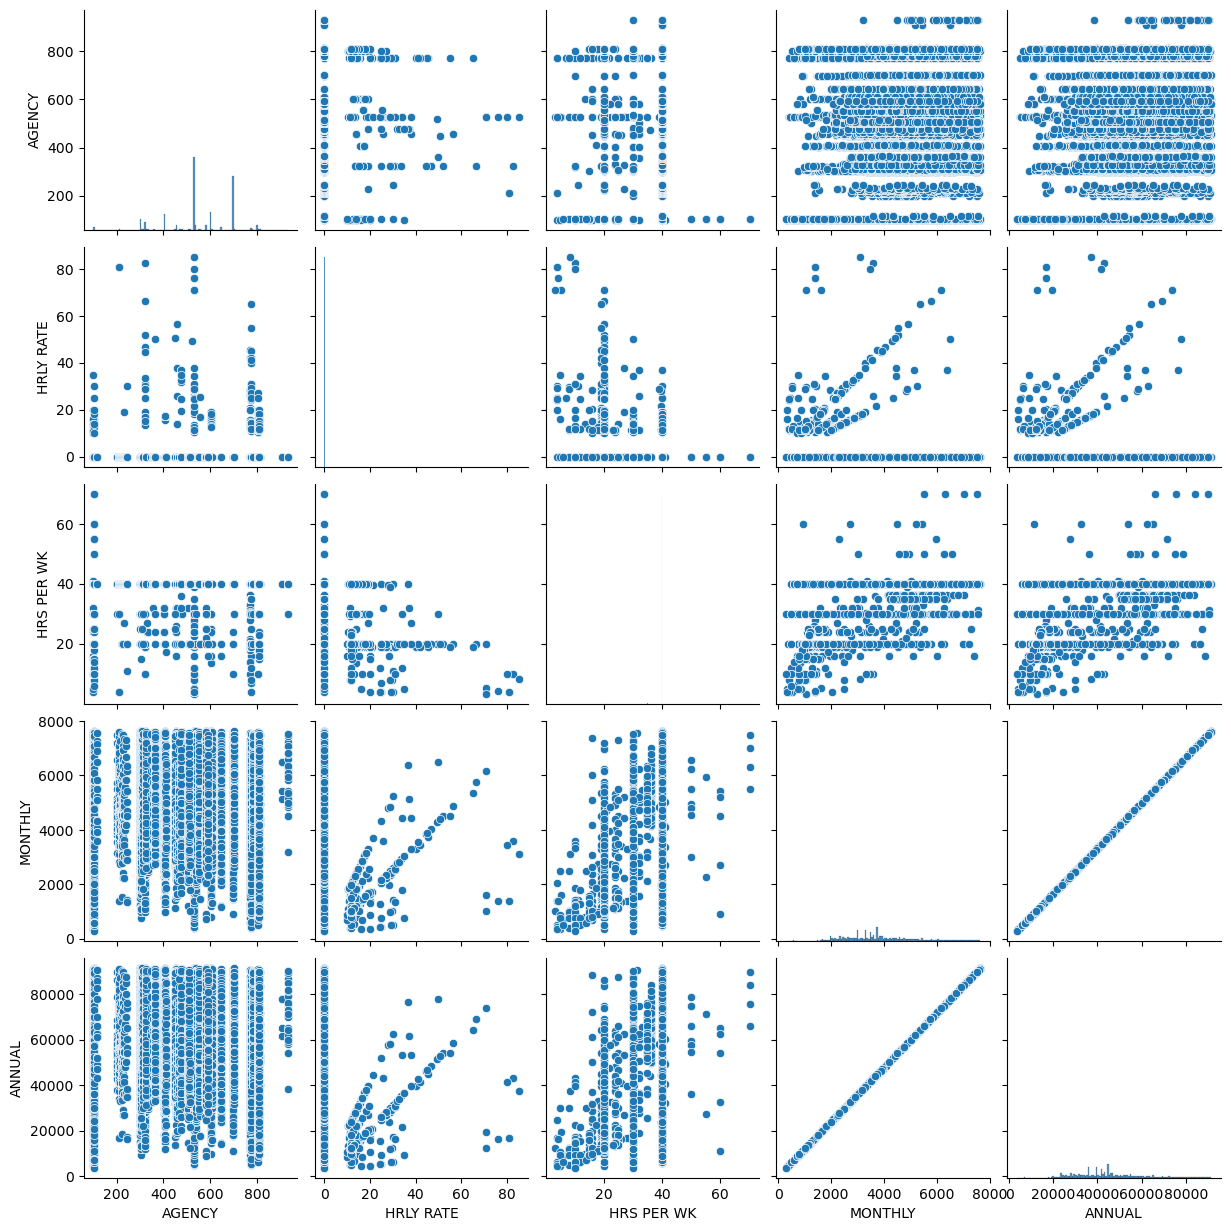

In [52]:
sns.pairplot(data=df)

# CORRELATION ANALYSIS

In [53]:
tc = df.corr(numeric_only=True)
print(tc)


              AGENCY  HRLY RATE  HRS PER WK   MONTHLY    ANNUAL
AGENCY      1.000000   0.047979   -0.044004 -0.196686 -0.196686
HRLY RATE   0.047979   1.000000   -0.300948 -0.099007 -0.099007
HRS PER WK -0.044004  -0.300948    1.000000  0.185100  0.185100
MONTHLY    -0.196686  -0.099007    0.185100  1.000000  1.000000
ANNUAL     -0.196686  -0.099007    0.185100  1.000000  1.000000


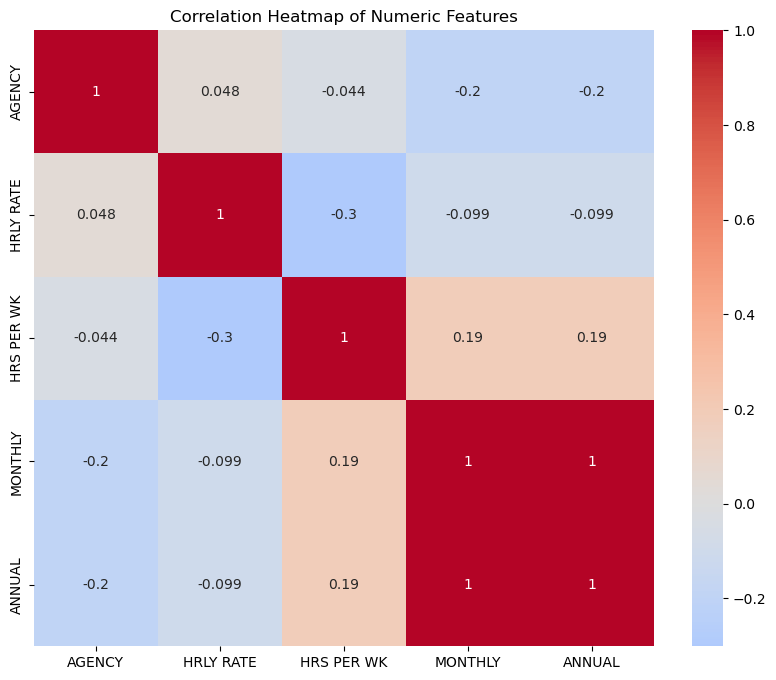

In [54]:
plt.figure(figsize=(10,8))
sns.heatmap(
    tc,              
    annot=True,     
    cmap="coolwarm",
    center=0         
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()


AS EXPECTED MONTHLY AND ANNUAL ARE HIGHLY CORRELATED ,HENCE ONE OF THEM CAN BE DROPPED

In [55]:
df.drop('MONTHLY',inplace=True,axis=1)

# 5.DATA PREPROCESSING

In [56]:

enc = LabelEncoder()
df[['AGENCY NAME','LAST NAME','FIRST NAME','MI','CLASS CODE','CLASS TITLE','GENDER','STATUS','ETHNICITY']] = df[['AGENCY NAME','LAST NAME','FIRST NAME','MI','CLASS CODE','CLASS TITLE','GENDER','STATUS','ETHNICITY']].apply(enc.fit_transform)

df[['AGENCY NAME','LAST NAME','FIRST NAME','MI','CLASS CODE','CLASS TITLE','GENDER','STATUS','ETHNICITY']]

,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,GENDER,STATUS,ETHNICITY
1,47,28734,14826,22,557,441,1,4,5
3,47,31297,9742,10,557,441,1,4,5
4,86,24991,6749,0,732,228,0,0,3
6,89,28015,22163,10,348,218,1,0,5
8,4,31354,4768,4,1160,384,1,6,5
...,...,...,...,...,...,...,...,...,...
149476,75,35217,9742,16,958,1012,1,0,5
149477,75,35624,6819,1,78,1195,0,0,5
149478,75,35896,5410,3,4,258,1,1,5
149479,75,36122,5912,18,250,833,1,0,5


In [57]:
df.shape

(140450, 14)

In [58]:
df.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,ANNUAL
1,212,47,28734,14826,22,557,441,5,1,4,02/01/15,81.04454,4.0,16857.24
3,212,47,31297,9742,10,557,441,5,1,4,09/01/18,81.04453,4.0,16857.24
4,696,86,24991,6749,0,732,228,3,0,0,06/29/20,0.00000,40.0,39411.24
6,601,89,28015,22163,10,348,218,5,1,0,06/22/20,0.00000,40.0,70026.00
8,520,4,31354,4768,4,1160,384,5,1,6,03/04/20,49.40717,20.0,51383.40


# 6.MODEL CREATION

In [59]:
x =df.drop(['ANNUAL','EMPLOY DATE','LAST NAME','MI','FIRST NAME','AGENCY'],axis=1)
y = df['ANNUAL']

In [60]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=33)

In [61]:
SC = StandardScaler()
x_train_scaled = SC.fit_transform(x_train)
x_test_scaled = SC.transform(x_test)

In [62]:
x_train_scaled

array([[ 0.94857917,  0.44674331, -0.82233225, ..., -0.15999188,
        -0.09009152,  0.11791742],
       [-0.71712399,  0.75713015, -0.6210233 , ..., -0.15999188,
        -0.09009152,  0.11791742],
       [-0.71712399, -1.30723513, -1.42625908, ..., -0.15999188,
        -0.09009152,  0.11791742],
       ...,
       [-1.10696941, -1.38922411,  1.29428752, ..., -0.15999188,
        -0.09009152,  0.11791742],
       [-0.11463561, -1.66740099, -1.34861135, ..., -0.15999188,
        -0.09009152,  0.11791742],
       [ 0.94857917,  1.6033735 ,  0.14107485, ..., -0.15999188,
        -0.09009152,  0.11791742]], shape=(112360, 8))

# a.LINEAR REGRESSION

In [63]:
LR = LinearRegression()
LR.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
y_pred1 = LR.predict(x_test_scaled)
y_pred1

array([41964.88723827, 53192.33409721, 41964.88723827, ...,
       52637.10497165, 48211.40431439, 49241.21546773], shape=(28090,))

In [65]:
print(mean_squared_error(y_test,y_pred1))

213579163.9183975


In [66]:
print(mean_absolute_error(y_test,y_pred1))

11425.05699460983


In [67]:
print(r2_score(y_test,y_pred1))

0.12284611027566594


# 2.GRADIENT BOOSTING

In [68]:
! pip install xgboost

In [69]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(max_depth=10,
    n_estimators=1000,
    min_child_weight=0.5, 
    colsample_bytree=0.8, 
    subsample=0.8, 
    eta=0.1,
    seed=42
)

In [70]:
xgb_model.fit(
    x_train_scaled, 
    y_train, 
    eval_set=[(x_train_scaled, y_train)], 
)


[0]	validation_0-rmse:14470.02426
[1]	validation_0-rmse:13400.37500
[2]	validation_0-rmse:12443.44202
[3]	validation_0-rmse:11657.30832
[4]	validation_0-rmse:10918.98958
[5]	validation_0-rmse:10256.40599
[6]	validation_0-rmse:9677.54869
[7]	validation_0-rmse:9229.96365
[8]	validation_0-rmse:8825.23845
[9]	validation_0-rmse:8432.29211
[10]	validation_0-rmse:8080.30664
[11]	validation_0-rmse:7770.68591
[12]	validation_0-rmse:7518.59425
[13]	validation_0-rmse:7309.64750
[14]	validation_0-rmse:7107.53723
[15]	validation_0-rmse:6942.97835
[16]	validation_0-rmse:6759.71674
[17]	validation_0-rmse:6636.39249
[18]	validation_0-rmse:6535.39917
[19]	validation_0-rmse:6462.35428
[20]	validation_0-rmse:6336.05797
[21]	validation_0-rmse:6217.65941
[22]	validation_0-rmse:6121.46495
[23]	validation_0-rmse:6051.65476
[24]	validation_0-rmse:6000.39209
[25]	validation_0-rmse:5944.56299
[26]	validation_0-rmse:5915.62049
[27]	validation_0-rmse:5857.27029
[28]	validation_0-rmse:5771.64944
[29]	validation_0-

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [71]:
y_predict_train = xgb_model.predict(x_train_scaled)
predict_xgb = xgb_model.predict(x_test_scaled)


In [72]:
predict_xgb

array([40263.586, 50325.285, 40263.586, ..., 48273.555, 29716.416,
       45888.754], shape=(28090,), dtype=float32)

In [73]:
from sklearn.metrics import explained_variance_score
print(explained_variance_score(predict_xgb,y_test))

0.8798789370731404


In [74]:
rmse = np.sqrt(mean_squared_error(y_test, predict_xgb))
print(rmse)
print(mean_squared_error(y_test, predict_xgb))
print(r2_score(y_test, predict_xgb))

5158.835144907834
26613580.05233623
0.8906999876106088


# 3.RANDOM FOREST REGRESSOR

In [75]:
forest_model = RandomForestRegressor(n_estimators=100, verbose=3,n_jobs=-1, random_state=0)
forest_model.fit(x_train_scaled,y_train)
forest_pred = forest_model.predict(x_test_scaled)
print(mean_absolute_error(forest_pred, y_test))

building tree 1 of 100building tree 7 of 100
building tree 3 of 100
building tree 11 of 100
building tree 12 of 100
building tree 10 of 100
building tree 8 of 100
building tree 5 of 100

building tree 6 of 100
building tree 9 of 100
building tree 4 of 100
building tree 2 of 100
building tree 13 of 100
building tree 14 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.


building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100


[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.4s


building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.6s finished
[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   4 tasks      | elapsed:    0.0s


2583.9495651236844


[Parallel(n_jobs=14)]: Done 100 out of 100 | elapsed:    0.1s finished


In [76]:
print(r2_score(y_test, forest_pred))

0.9182782857136718


# 4.DECISION TREE

In [77]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()

In [78]:
dtr.fit(x_train_scaled,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [79]:
y_pred = dtr.predict(x_test_scaled)

In [80]:
y_pred

array([40295.99068783, 50317.8       , 40295.99068783, ...,
       53804.1       , 29853.33714286, 46098.        ], shape=(28090,))

In [81]:
print(r2_score(y_test,y_pred))

0.9062657639661681


In [82]:
# COMPARING MSE AND MAE

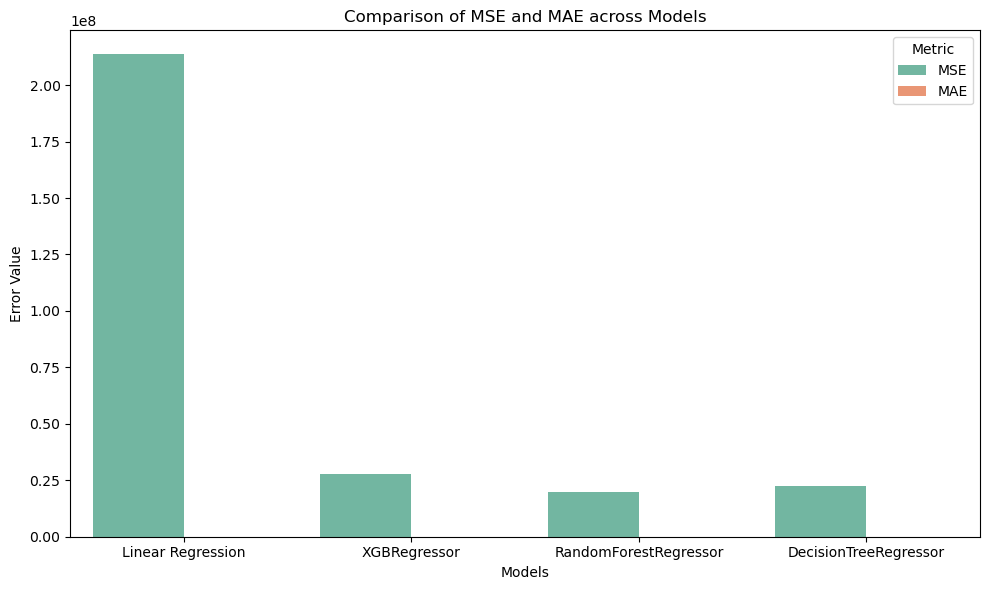

In [83]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'XGBRegressor': XGBRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'DecisionTreeRegressor': DecisionTreeRegressor()
}

mse_scores = {}
mae_scores = {}

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse_scores[model_name] = mean_squared_error(y_test, y_pred)
    mae_scores[model_name] = mean_absolute_error(y_test, y_pred)

# Convert results to DataFrame
results = pd.DataFrame({
    'Model': list(mse_scores.keys()),
    'MSE': list(mse_scores.values()),
    'MAE': list(mae_scores.values())
})

# Melt for grouped bar chart
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Error')

# Best visualization: grouped bar chart
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Error', hue='Metric', data=results_melted, palette='Set2')

plt.title('Comparison of MSE and MAE across Models')
plt.xlabel('Models')
plt.ylabel('Error Value')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


# MODEL COMPARISON

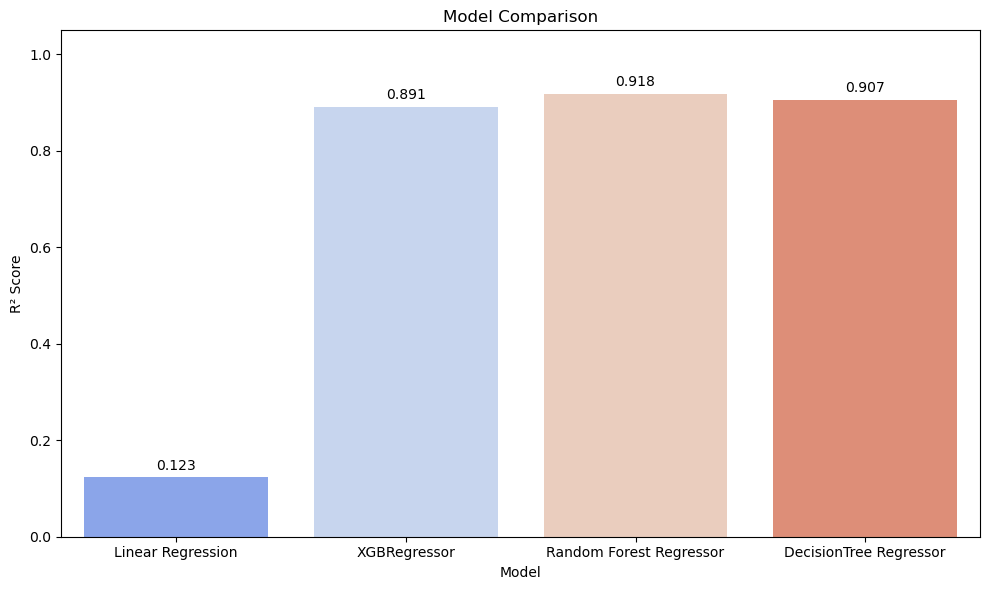

In [84]:
# Define models and R² scores
models = ['Linear Regression', 'XGBRegressor', 'Random Forest Regressor', 'DecisionTree Regressor']
R2 = [0.1228461102, 0.8906999876106088, 0.9182782857136718, 0.9065198572165227]

# Create bar plot
plt.figure(figsize=(10,6))
sns.barplot(x=models, y=R2, palette='coolwarm')

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model Comparison')

# Annotate bars with exact values
for i, score in enumerate(R2):
    plt.text(i, score + 0.01, f"{score:.3f}", ha='center', va='bottom')

plt.ylim(0, 1.05) 
plt.tight_layout()
plt.show()


INSIGHTS : RANDOM FOREST REGRESSOR is the best performing model with a R2 score of
0.91

# 1.FINDING OUTLIERS

In [85]:
lower_ANNUAL,upper_ANNUAL

(np.float64(3010.6200000000026), np.float64(91617.18))

In [86]:
data = pd.read_csv(r"C:\Users\DELL\Downloads\salary.csv")

In [87]:
indices = np.where((data['ANNUAL'] > 91617.18) | (data['ANNUAL'] < 3010.62))
outliers = data.iloc[indices]
outliers

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.9615,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.9615,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
5,302,OFFICE OF THE ATTORNEY GENERAL ...,ROGERS,SHAUNA,,1623,DIRECTOR IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.0000,40.0,12899.00,154788.00,1177785,True,1.0,NaN,NaN,NaN
7,510,TEXAS BEHAVIORAL HEALTH EXECUTIVE COUNCIL ...,SPINKS,DARREL,D,1623,DIRECTOR IV ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.0000,40.0,10000.00,120000.00,147334,True,NaN,NaN,171383.40,NaN
36,101,SENATE ...,BARNETT,ANNA,P,7101,LEG. OFFICIAL/ADMINISTRATOR ...,WHITE,FEMALE,URF - UNCLASSIFIED REGULAR FULL-TIME,...,0.0000,40.0,8000.00,96000.00,49800,True,NaN,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149374,809,STATE PRESERVATION BOARD ...,KOCH,MARGARET,M,1623,DIRECTOR IV ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.0000,40.0,10583.34,127000.08,336971,NaN,NaN,NaN,NaN,NaN
149393,809,STATE PRESERVATION BOARD ...,MEDINA,JOE,,1603,MGR IV ...,HISPANIC,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.0000,40.0,8358.41,100300.92,9905,NaN,NaN,NaN,NaN,NaN
149401,809,STATE PRESERVATION BOARD ...,NUNN,CHRISTOPHER,L,1602,MGR III ...,BLACK,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.0000,40.0,7916.67,95000.04,38235,NaN,NaN,NaN,NaN,NaN
149415,809,STATE PRESERVATION BOARD ...,PROVINE,CYNTHIA,R,1622,DIRECTOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.0000,40.0,10188.09,122257.08,52817,NaN,NaN,NaN,NaN,NaN


In [88]:
high_outliers = outliers.loc[outliers['ANNUAL'] > 400000]
high_outliers

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
14793,323,TEACHER RETIREMENT SYSTEM ...,AUBY,JASE,R,C204,CHIEF INVESTMENT OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,...,0.0,40.0,37500.0,450000.0,121522,NaN,NaN,NaN,NaN,NaN
83851,542,CANCER PREVENTION AND RESEARCH INSTITUTE OF TE...,WILLSON,JAMES,,C542,CHIEF SCIENTIFIC OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,...,0.0,40.0,46125.0,553500.0,372291,NaN,NaN,NaN,NaN,NaN
144232,327,EMPLOYEES RETIREMENT SYSTEM ...,TULL,CHARLES,T,D136,DIRECTOR OF INVESTMENTS ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,...,0.0,40.0,37500.0,450000.0,24680,NaN,NaN,NaN,NaN,NaN


Top 3 Highest Paid Outliers Identified:

Chief Scientific Officer at the Cancer Prevention and Research Institute of Texas - $553,500.00

Chief Investment Officer at the Teacher Retirement System - $450,000.00

Director of Investments at the Employees Retirement System - $450,000.00

Key Observation: The outliers are heavily concentrated in the Financial (Retirement Systems) and Medical Research sectors. These roles require highly specialized skills that demand market-competitive salaries significantly higher than the standard government pay scale."


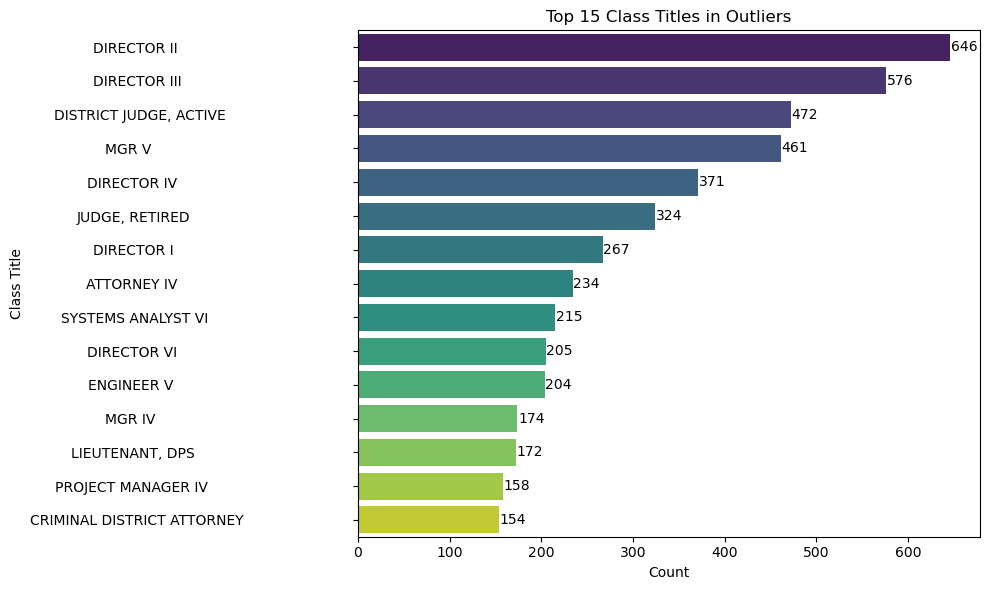

In [89]:
outliers['CLASS TITLE'].value_counts()

class_counts = outliers['CLASS TITLE'].value_counts().head(15)  # Top 15

plt.figure(figsize=(10,6))
sns.barplot(
    x=class_counts.values,
    y=class_counts.index,
    palette="viridis"
)

plt.title("Top 15 Class Titles in Outliers")
plt.xlabel("Count")
plt.ylabel("Class Title")

# Annotate counts on bars
for index, value in enumerate(class_counts.values):
    plt.text(value + 0.5, index, str(value), color='black', va='center')

plt.tight_layout()
plt.show()


# 2.What departments/roles have the biggest wage disparities between managers and employees?

In [90]:
data['CLASS TITLE'].unique()

array(['JUDGE, RETIRED                                    ',
       'GENERAL COUNSEL IV                                ',
       'CORREC  OFFICER IV                                ', ...,
       'CURATOR III                                       ',
       'CURATOR IV                                        ',
       'EQUIPMENT MAINT TECH I                            '],
      shape=(1422,), dtype=object)

In [91]:
def classify_role(title):
    title=str(title).upper()

    if any(keyword in title for keyword in ['MANAGER', 'DIRECTOR', 'CHIEF', 'SUPERVISOR', 'HEAD', 'COMMISSIONER','JUDGE']):
        return 'Manager'
    else:
        return 'Employee'

data['Role_Type'] = data['CLASS TITLE'].apply(classify_role)

In [92]:
data.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search,Role_Type
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN,Manager
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True,Employee
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN,Manager
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True,Employee
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN,Employee


In [93]:
AGENCY_PAY = data.groupby(['AGENCY NAME','Role_Type'])['ANNUAL'].mean().unstack()
AGENCY_PAY

Role_Type,Employee,Manager
AGENCY NAME,,
ALCOHOLIC BEVERAGE COMMISSION,58186.215754,124199.419200
BOARD OF ARCHITECTURAL EXAMINERS,75125.086667,145604.640000
BOARD OF CHIROPRACTIC EXAMINERS,59073.386667,100830.000000
BOARD OF DENTAL EXAMINERS,50648.692075,97333.320000
BOARD OF EXAMINERS OF PSYCHOLOGISTS,46863.136000,NaN
...,...,...
THIRD COURT OF APPEALS DISTRICT,92608.308387,187800.000000
THIRTEENTH COURT OF APPEALS DISTRICT,96848.544828,187800.000000
TREASURY SAFEKEEPING TRUST COMPANY,95037.450000,165747.855652


In [94]:
AGENCY_PAY['Wage_Gap'] = AGENCY_PAY['Manager'] - AGENCY_PAY['Employee']

In [95]:
top_gap_agencies = AGENCY_PAY.sort_values(by='Wage_Gap', ascending=False).head(10)

In [96]:
top_gap_agencies

Role_Type,Employee,Manager,Wage_Gap
AGENCY NAME,,,
CANCER PREVENTION AND RESEARCH INSTITUTE OF TEXAS,72609.621818,206399.138182,133789.516364
THIRD COURT OF APPEALS DISTRICT,92608.308387,187800.000000,95191.691613
SECOND COURT OF APPEALS DISTRICT,93137.108571,187800.000000,94662.891429
SAVINGS AND LOAN DEPARTMENT,64207.171304,158081.184000,93874.012696
TEACHER RETIREMENT SYSTEM,78192.117214,170189.109882,91996.992669
NINTH COURT OF APPEALS DISTRICT,95892.942000,187800.000000,91907.058000
THIRTEENTH COURT OF APPEALS DISTRICT,96848.544828,187800.000000,90951.455172
FIFTH COURT OF APPEALS DISTRICT,97409.764068,187800.000000,90390.235932
OFFICE OF CAPITAL AND FORENSIC WRITS,61571.238000,148509.960000,86938.722000


# TOP 3 AGENCIES WITH BIGGEST WAGE GAP

1.CANCER PREVENTION AND RESEARCH INSTITUTE OF TEXAS	:

This agnecy shows high disparity of 133789.516364
REASON : This agency has significant roles of highly specialized medical direcotrs and scientists which demands
high payrolls

2.THIRD COURT OF APPEALS DISTRICT:

There is significant wage gap of 95191 between judge and other administrative staff

3.SECOND COURT OF APPEALS DISTRICT:

The wage gap is 94662.

# 3.Have salaries and total compensations for some roles/ departments/ head-count changed over time?

In [97]:
data['EMPLOY DATE'] = pd.to_datetime(data['EMPLOY DATE'],errors='coerce')

In [98]:
data['EMPLOY DATE'].value_counts()

EMPLOY DATE
2017-09-01    12359
2016-09-01     3261
2004-09-01     1529
2020-06-01     1171
2020-02-01      767
              ...  
2006-03-14        1
2014-05-28        1
2019-03-22        1
2012-04-20        1
1989-09-22        1
Name: count, Length: 6295, dtype: int64

In [99]:
data['hiring_year'] = data['EMPLOY DATE'].dt.year

In [100]:
# filter data between 1990 t0 2000
trend_data = data[(data['hiring_year'] >= 1990) & (data['hiring_year'] <= 2020)].copy()

In [101]:
yearly_trend = yearly_trend = trend_data.groupby('hiring_year').agg(
    avg_salary=('ANNUAL', 'mean'),
    headcount=('AGENCY NAME', 'count')
)

In [102]:
yearly_trend

,avg_salary,headcount
hiring_year,,
1990,76973.553889,216
1991,78726.484138,203
1992,68835.133855,511
1993,71186.671893,523
1994,70762.156634,725
1995,69224.734884,774
1996,64716.474379,918
1997,67816.591125,960
1998,65683.742281,1210


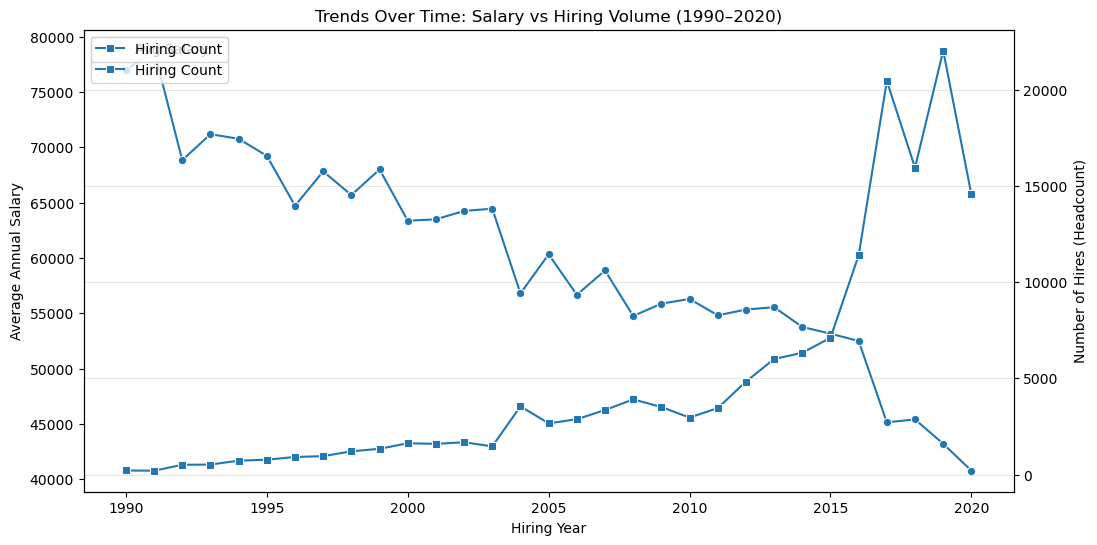

In [103]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot average salary
sns.lineplot(
    x=yearly_trend.index,
    y=yearly_trend['avg_salary'],
    ax=ax1,
    marker='o',
    label='Avg Salary'
)

ax1.set_ylabel('Average Annual Salary')
ax1.set_xlabel('Hiring Year')

# Plot headcount on secondary axis
ax2 = ax1.twinx()
sns.lineplot(
    x=yearly_trend.index,
    y=yearly_trend['headcount'],
    ax=ax2,
    marker='s',
    label='Hiring Count'
)

ax2.set_ylabel('Number of Hires (Headcount)')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Trends Over Time: Salary vs Hiring Volume (1990–2020)')
plt.grid(True, alpha=0.3)
plt.show()


Salary Trend:

The average annual salary steadily declined from the early 1990s through 2020, moving from around $75,000 down toward $45,000–50,000.

This suggests either wage compression, shifts toward lower‑paying roles, or changes in the composition of hires (more entry‑level positions being added).

 Hiring Volume Trend:

Headcount remained relatively stable until about 2010, then surged sharply around 2015, peaking near 20,000 hires.

After 2015, hiring volume dropped again by 2020, showing a boom‑and‑bust cycle in recruitment.

Combined Insights:

The inverse relationship is striking: as hiring volume increased, average salaries decreased.

This often indicates expansion in lower‑wage, high‑volume roles (e.g., support staff, service positions).

Meanwhile, fewer high‑salary managerial or specialized roles were added, pulling the average down.

The 2015 spike suggests a major hiring drive — possibly tied to policy changes, economic growth, or sectoral expansion — but it was concentrated in lower‑paying jobs.

By 2020, both salaries and headcount declined, hinting at contraction or restructuring.

Key Takeaways:

Wage disparity widened: fewer high‑salary hires, more low‑salary hires.

Hiring surges don’t guarantee wage growth — in fact, they can dilute averages if concentrated in lower‑paying roles.

Strategic workforce planning is crucial: balancing headcount growth with compensation to avoid long‑term wage stagnation.



# CHALLENGES

Data Preprocessing and Modeling Challenges  
The dataset required extensive preprocessing due to the presence of null values, outliers, and inconsistent formatting. To ensure data integrity, columns with more than 70% missing values were dropped. Outliers were identified and removed using the Interquartile Range (IQR) method, thereby improving the accuracy and reliability of the dataset.

Selecting an appropriate machine learning algorithm posed an additional challenge, as different models exhibited varying levels of performance depending on the data characteristics. Beyond model selection, a key difficulty lay in interpreting results and communicating prediction outcomes in a clear and accessible manner. Translating complex statistical insights into simple, understandable explanations was particularly important when presenting findings to non‑technical stakeholders.

# CONCLUSION

The Texas Employee Salary Dataset was analyzed to uncover salary trends over time and to develop an effective predictive model. Extensive preprocessing was performed to address data quality issues, including handling null values and removing outliers, thereby improving the reliability and accuracy of the dataset for modeling.

Among the models evaluated, the Random Forest Regressor, optimized through hyperparameter tuning, emerged as the best-performing algorithm. It achieved an R² score of 0.91 with a low error rate, demonstrating strong generalization to unseen samples and delivering highly accurate predictions. This performance highlights the model’s robustness in capturing complex salary patterns and its suitability for predictive analytics in workforce compensation studies.